# Tổng quan dự án — Bài tập Strategy RSI (Phase 1)

## 1) Mục tiêu & Phạm vi
- **Mục tiêu chính:** Xây dựng và *hiểu rõ* một chiến lược RSI đơn giản trên crypto (BTC), gồm pipeline dữ liệu → tín hiệu → backtest → phân tích kết quả.
- **Phạm vi Phase 1:**  
  - Dữ liệu **1D OHLCV** crawl trực tiếp (không dùng bộ tĩnh).  
  - Chiến lược **RSI stateful** (mua khi quá bán, giữ đến khi quá mua).  
  - Backtest **long-only**, close-to-close, **khớp lệnh T+1** (no-lookahead).  
  - Phí & trượt giá cố định: **5 bps** + **2 bps** mỗi lần đổi trạng thái.  
  - Trọng tâm: *giải thích được* thay vì tối đa hoá kết quả bằng mọi giá.

---

## 2) Pipeline dữ liệu
- **Crawl:** `ccxt` với fallback đa sàn (bybit → **okx** → kraken → kucoin → coinbase → bitfinex → gateio).  
- **Chuẩn hoá:** chuẩn Phase 1 → `index = UTC`, cột: `open, high, low, close, volume`.  
- **Integrity checks:** sort ↑, loại trùng, kiểm tra missing 1D (BTC hầu như không thiếu), ép số & `close > 0`.

*Kết quả crawl mẫu:*  
- Sàn: **OKX**, Symbol: **BTC/USDT**  
- Khoảng: **2019-09-01 → 2025-10-29**, **2251** dòng, missing 1D = **0**.

---

## 3) Khung backtest (tối giản, mô-đun)
- **Engine:** vectorized Pandas; `net_ret_t = pos_{t-1} * ret_t − 1{trade_t}·(fee+slip)`.  
- **No-lookahead:** tín hiệu được **shift(1)**, áp dụng từ phiên kế tiếp.  
- **Báo cáo:** `Cumulative Return`, `Sharpe (daily,252)`, `Max Drawdown`, `Trades`, `Exposure%`.  
- **Blotter:** ghi lại `pos_prev/pos`, `trade`, `net_ret`, `equity`.

---

## 4) Chiến lược RSI (stateful)
- **RSI(14) — Quy tắc:**
  - **Vào** khi `RSI < buy_th`.  
  - **Giữ** cho tới khi `RSI > sell_th` thì **thoát**.  
  - Sau đó **shift(1)** để khớp tại **T+1**.
- **Lý do chọn:** minh bạch, dễ giải thích; phù hợp mục tiêu Phase 1.

---

## 5) Kết quả chính (mặc định 14 | 30/70)
- **RSI (stateful):**  
  - CumRet ≈ **1.26**, Sharpe ≈ **0.45**, MDD ≈ **−50%**, Trades ≈ **18**, Exposure ≈ **34%**.
- **Buy&Hold:**  
  - CumRet ≈ **9.85**, Sharpe ≈ **0.78**, MDD ≈ **−77%**, Trades = **1**, Exposure ≈ **100%**.
- **Giải thích:**  
  - RSI là chiến lược **mean-reversion** → bỏ lỡ nhiều đoạn **bull trend** kéo dài của BTC.  
  - **Exposure thấp** nên tích lũy kém hơn BH dù MDD giảm tương đối.

---

## 6) Phân tích sâu (regime & sensitivity)
- **Regime (SMA200 + slope):**  
  - **Bull:** RSI có Sharpe dương và CumRet dương (bắt kéo sau quá bán).  
  - **Bear:** hiệu quả giảm hoặc âm (tỉ lệ false-mean-revert cao hơn).
- **Sensitivity (period=14):**  
  - Lưới ngưỡng (25/75, 30/70, 35/65) cho thấy mốc **25/75** cải thiện Sharpe so với **30/70**.  
- **Grid search chi tiết:**  
  - Tìm ngưỡng tối ưu trên toàn mẫu (ràng buộc trades & gap) → **buy=21 / sell=89**,  
    **Sharpe ≈ 1.05**, **CumRet ≈ 16.75**, **Trades ≈ 5**, **Exposure ≈ 65%**.  
  - **Cảnh báo:** tối ưu toàn mẫu dễ **overfit** → cần kiểm tra out-of-sample.

---

## 7) Kiểm chứng chất lượng (Phase 1 QA)
- **No-lookahead:** `pos_prev == signal.shift(1)` → OK (assert).  
- **Kế toán PnL:** `equity = start_cash · (1+net_ret).cumprod()` → OK.  
- **Phí & slippage:** chỉ tính khi `trade > 0` (đổi trạng thái) → OK.  
- **Sanity synthetic:** up-only / flat kiểm tra kỳ vọng → OK.

---

## 8) Bài học chính
1. **Tín hiệu phải stateful** đúng định nghĩa; phiên bản “RSI<30 → 1, otherwise 0” gây **thoát sớm** và sai kỳ vọng.  
2. **No-lookahead là bắt buộc**: quyết định hôm nay chỉ được khớp từ **ngày mai**.  
3. **Regime matters:** RSI hợp cảnh **sideways/mean-revert**, kém hơn **trend-following** khi thị trường uptrend mạnh.  
4. **Tham số ảnh hưởng lớn**: ngưỡng rộng hơn (ví dụ 21/89) cải thiện Sharpe nhưng có thể tăng MDD/overfit.  
5. **Backtest minh bạch > “điểm số đẹp”**: báo cáo phải dẫn giải được cơ chế sinh lời/thua lỗ, không chỉ con số.

---

## 9) Hướng phát triển (sau Phase 1)
- **Đánh giá ngoài mẫu:** train/test theo thời gian, **walk-forward**.  
- **Chính sách thoát mềm:** trailing-stop, time-stop, hoặc bán một phần khi RSI quay lại vùng trung tính.  
- **Kết hợp regime filter:** chỉ kích hoạt RSI khi dưới SMA200 (bear/sideways), hoặc khi biến động đạt ngưỡng.  
- **Danh mục đa tài sản:** mở rộng sang ETH/BNB/... để giảm rủi ro idiosyncratic.  
- **Chuẩn hoá framework:** tách file `backtest_core.py` (engine) và notebook (phân tích) để tái sử dụng.

---

## 10) Kết luận ngắn
Dự án hoàn thành mục tiêu Phase 1: **pipeline dữ liệu chuẩn**, **engine backtest tối giản và đúng đắn**, **chiến lược RSI stateful minh bạch**, cùng các **phân tích định tính/định lượng** (regime & sensitivity). Kết quả cho thấy RSI cơ bản **không đánh bại** Buy&Hold trên BTC giai đoạn dài, nhưng việc hiểu **khi nào RSI hiệu quả** và **tại sao** là nền tảng quan trọng trước khi bước sang Phase 2 (out-of-sample, cải tiến logic, và quản trị rủi ro).


### Cell 1 — Setup & Config (RSI)

**Mục tiêu:** Chuẩn bị môi trường cho bài RSI (crawl → tiền xử lý → backtest).

**Thành phần chính**
- Thư viện: `ccxt`, `pandas`, `numpy`, `matplotlib`, `pytz`.
- Cấu hình:
  - `EXCHANGE_NAME="binance"` *(Cell 2 có fallback nếu bị chặn)*
  - `SYMBOL="BTC/USDT"`, `TIMEFRAME="1d"`
  - `START_DATE="2019-09-01"`, `END_DATE=None`, `TZ="UTC"`
  - Phí/slippage: `FEE_BPS=5`, `SLIPPAGE_BPS=2`, vốn `START_CASH=10_000`
- Hiển thị & tái lập: thiết lập Pandas display, `np.random.seed(42)`.

**Kiểm tra:** In `ENV INFO` (Python, ccxt, symbol, timeframe, phí/slippage, TZ).

**Ghi chú sự cố & xử lý:** Một số vùng bị **Binance 451** → Cell 2 tự động **fallback** (OKX/…).


In [ ]:
# CELL 1 — Setup & Config (Colab)
# Mục tiêu: chuẩn bị môi trường cho bài RSI (crawling crypto → tiền xử lý → backtest).
# Lý do chọn: dùng ccxt để lấy OHLCV trực tiếp từ sàn (Binance mặc định).

# 1) Cài đặt & import
!pip -q install ccxt==4.* pandas numpy matplotlib pytz

import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytz, sys, platform, math, time, datetime as dt

# 2) Cấu hình thí nghiệm (có thể chỉnh)
EXCHANGE_NAME = "binance"     # sàn để crawl
SYMBOL        = "BTC/USDT"    # cặp crypto
TIMEFRAME     = "1d"          # khung thời gian
START_DATE    = "2019-09-01"  # ngày bắt đầu crawl (UTC)
END_DATE      = None          # để None = đến hiện tại
TZ            = "UTC"         # chuẩn hóa múi giờ (pipeline Phase 1)

# Tham số phí/slippage cho backtest Phase 1 (đơn giản, tính theo bps)
FEE_BPS       = 5             # 5 bps = 0.05% mỗi lần vào/ra
SLIPPAGE_BPS  = 2             # 2 bps = 0.02%
START_CASH    = 10_000

# 3) Thiết lập hiển thị & reproducibility
pd.options.display.width = 160
pd.options.display.max_columns = 20
np.set_printoptions(suppress=True)
np.random.seed(42)

print("== ENV INFO ==")
print("Python :", sys.version.split()[0], "| Platform:", platform.platform())
print("ccxt   :", ccxt.__version__)
print("Symbol :", SYMBOL, "| Timeframe:", TIMEFRAME)
print("Start  :", START_DATE, "| End:", END_DATE or "now (UTC)")
print("Fees   :", f"{FEE_BPS} bps", "| Slippage:", f"{SLIPPAGE_BPS} bps")
print("TZ     :", TZ)

# ✅ Tiếp theo (Cell 2): viết hàm crawl OHLCV bằng ccxt (không dùng dữ liệu tĩnh),
# trả về DataFrame chuẩn Phase 1: index=timestamp(UTC), cột ['open','high','low','close','volume'].


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.6/130.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 641.1/641.1 kB 23.5 MB/s eta 0:00:00
== ENV INFO ==
Python : 3.12.12 | Platform: Linux-6.6.105+-x86_64-with-glibc2.35
ccxt   : 4.5.13
Symbol : BTC/USDT | Timeframe: 1d
Start  : 2019-09-01 | End: now (UTC)
Fees   : 5 bps | Slippage: 2 bps
TZ     : UTC


### Cell 2B — Crawl OHLCV RAW (fallback nhiều sàn)

**Mục tiêu:** Tải dữ liệu OHLCV **thô** (chưa tiền xử lý) qua `ccxt`, tự động **fallback** nếu sàn bị chặn/rate limit.

**Quy trình:**
- Thử lần lượt: `bybit → okx → kraken → kucoin → coinbase → bitfinex → gateio`.
- Chọn symbol khả dụng (ưu tiên `BTC/USDT`, `BTC/USD`, `XBT/*`).
- Phân trang theo `timeframe`, ghép thành DataFrame thô.

**Input:** `TIMEFRAME="1d"`, `START_DATE="2019-09-01"`, `END_DATE=None`  
**Output:** `df_raw_ohlcv` (index=UTC), cột: `['timestamp','open','high','low','close','volume']` + `dt_utc` (index)

**Kết quả chạy mẫu:**
→ Thử sàn: okx | symbol: BTC/USDT
== RAW OHLCV DOWNLOADED ==
Exchange : okx
Symbol : BTC/USDT
Rows : 2251
Range UTC : 2019-09-01 → 2025-10-29
API calls : 8
**Sự cố & xử lý:**
- `Binance 451 (restricted location)` → fallback sang **OKX** (thành công).
- `403/RateLimit` → chờ `ex.rateLimit` giữa các lần gọi.

In [ ]:
# CELL 2B — Crawl OHLCV RAW với fallback nhiều sàn (không tiền xử lý)
# Thử lần lượt: bybit, okx, kraken, kucoin, coinbase, bitfinex, gateio
# Output: df_raw_ohlcv (index=datetime UTC), cột: ['timestamp','open','high','low','close','volume']

import time
import pandas as pd
import numpy as np
import ccxt

FALLBACK_EXCHANGES = ["bybit", "okx", "kraken", "kucoin", "coinbase", "bitfinex", "gateio"]

def pick_symbol_from_markets(ex, preferred=("BTC/USDT","BTC/USD","XBT/USDT","XBT/USD")):
    ex.load_markets()
    for s in preferred:
        if s in ex.markets:
            return s
    # nếu không có các cặp ưa thích, chọn cặp BTC/* đầu tiên có OHLCV
    for s, m in ex.markets.items():
        if ("BTC" in s or "XBT" in s) and m.get("active", True):
            return s
    raise RuntimeError("Không tìm được symbol BTC/* phù hợp trên sàn này.")

def crawl_ohlcv_raw_any(timeframe, start_date, end_date=None, limit_per_call=1000):
    since_ms = pd.Timestamp(start_date, tz="UTC").value // 10**6
    until_ms = (pd.Timestamp.utcnow().value // 10**6) if end_date is None else pd.Timestamp(end_date, tz="UTC").value // 10**6

    for ex_id in FALLBACK_EXCHANGES:
        try:
            ex = getattr(ccxt, ex_id)({"enableRateLimit": True})
            symbol = pick_symbol_from_markets(ex)
            print(f"→ Thử sàn: {ex_id} | symbol: {symbol}")
            step_ms = ex.parse_timeframe(timeframe) * 1000

            all_parts, calls = [], 0
            cursor = since_ms

            while True:
                batch = ex.fetch_ohlcv(symbol, timeframe=timeframe, since=cursor, limit=limit_per_call)
                calls += 1
                if not batch:
                    break
                part = pd.DataFrame(batch, columns=["timestamp","open","high","low","close","volume"])
                all_parts.append(part)
                next_ms = int(part["timestamp"].iloc[-1]) + step_ms
                if next_ms > until_ms:
                    break
                cursor = next_ms
                time.sleep(ex.rateLimit / 1000)

            if not all_parts:
                print(f"⚠️ Không lấy được dữ liệu từ {ex_id}, thử sàn tiếp theo…")
                continue

            raw = pd.concat(all_parts, ignore_index=True)
            raw["dt_utc"] = pd.to_datetime(raw["timestamp"], unit="ms", utc=True)
            df_raw_ohlcv = raw.set_index("dt_utc")

            print("== RAW OHLCV DOWNLOADED ==")
            print("Exchange  :", ex_id)
            print("Symbol    :", symbol)
            print("Rows      :", len(df_raw_ohlcv))
            print("Range UTC :", df_raw_ohlcv.index.min(), "→", df_raw_ohlcv.index.max())
            print("API calls :", calls)
            return df_raw_ohlcv, ex_id, symbol

        except Exception as e:
            print(f"✖ {ex_id} lỗi: {type(e).__name__}: {e}. Thử sàn tiếp theo…")
            continue

    raise RuntimeError("Tất cả sàn trong fallback đều thất bại. Hãy đổi mạng/VPN hoặc thử timeframe/ khoảng thời gian khác.")

# GỌI HÀM (dùng TIMEFRAME, START_DATE, END_DATE đã đặt ở Cell 1)
df_raw_ohlcv, USED_EXCHANGE, USED_SYMBOL = crawl_ohlcv_raw_any(
    timeframe=TIMEFRAME,
    start_date=START_DATE,
    end_date=END_DATE,
    limit_per_call=1000
)

# Xem vài dòng đầu/cuối (thô)
display(df_raw_ohlcv.head(5))
display(df_raw_ohlcv.tail(5))


✖ bybit lỗi: RateLimitExceeded: bybit GET https://api.bybit.com/v5/market/instruments-info?category=spot 403 Forbidden <!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN" "http://www.w3.org/TR/html4/loose.dtd">
<HTML><HEAD><META HTTP-EQUIV="Content-Type" CONTENT="text/html; charset=iso-8859-1">
<TITLE>ERROR: The request could not be satisfied</TITLE>
</HEAD><BODY>
<H1>403 ERROR</H1>
<H2>The request could not be satisfied.</H2>
<HR noshade size="1px">
The Amazon CloudFront distribution is configured to block access from your country.
We can't connect to the server for this app or website at this time. There might be too much traffic or a configuration error. Try again later, or contact the app or website owner.
<BR clear="all">
If you provide content to customers through CloudFront, you can find steps to troubleshoot and help prevent this error by reviewing the CloudFront documentation.
<BR clear="all">
<HR noshade size="1px">
<PRE>
Generated by cloudfront (CloudFront)
Reques

,timestamp,open,high,low,close,volume
dt_utc,,,,,,
2019-09-01 00:00:00+00:00,1567296000000,9589.1,9822.8,9519.2,9733.5,6076.788464
2019-09-02 00:00:00+00:00,1567382400000,9733.5,10450.0,9717.3,10343.8,16994.528201
2019-09-03 00:00:00+00:00,1567468800000,10345.0,10780.0,10269.7,10614.1,20903.142385
2019-09-04 00:00:00+00:00,1567555200000,10614.2,10806.5,10372.8,10562.2,16492.537402
2019-09-05 00:00:00+00:00,1567641600000,10562.2,10650.0,10450.0,10562.1,11011.121248


,timestamp,open,high,low,close,volume
dt_utc,,,,,,
2025-10-25 00:00:00+00:00,1761350400000,111009.9,111950.0,110663.3,111650.0,2966.226549
2025-10-26 00:00:00+00:00,1761436800000,111650.0,115590.0,111250.2,114554.6,5405.328157
2025-10-27 00:00:00+00:00,1761523200000,114555.7,116400.0,113850.0,114111.7,8251.601714
2025-10-28 00:00:00+00:00,1761609600000,114111.8,116100.0,112200.0,112892.9,7869.525592
2025-10-29 00:00:00+00:00,1761696000000,112892.9,112901.0,112300.0,112315.0,306.082763


### Cell 3 — Standardize & Integrity Checks

**Mục tiêu:** Chuẩn hoá khung dữ liệu về chuẩn Phase 1 và kiểm tra tính toàn vẹn trước khi tính RSI.

**Các bước chính**
- Giữ cột: `open, high, low, close, volume` → ép `float`, lọc `close > 0`.
- Đặt index dạng `DatetimeIndex` **UTC**, sắp xếp tăng dần.
- Loại trùng timestamp (nếu có), **không** resample (1D liền mạch).
- Kiểm tra nhanh: **duplicates**, **missing (1D)**, **NA**, thống kê `return`.

**Kết quả chạy**
Rows : 2251
Range (UTC) : 2019-09-01 → 2025-10-29
Duplicates : 0
Missing 1D : 0
NA in price : 0
Return mean/std: 0.0016276 / 0.0325493

**Ghi chú sự cố & xử lý**
- Nếu gặp index không phải datetime/không UTC → `tz_localize('UTC')/tz_convert('UTC')`.
- Nếu có bản ghi trùng thời gian → giữ bản ghi **cuối**.
- Nếu có giá ≤ 0 hoặc NA → **loại** bản ghi.



In [ ]:
# CELL 3 — Standardize & Integrity Checks
# Input : df_raw_ohlcv (Cell 2B)
# Output: df (index=UTC datetime, cols=['open','high','low','close','volume']) + report nhanh

import pandas as pd
import numpy as np

# 1) Giữ đúng cột & ép kiểu
df = df_raw_ohlcv.copy()
keep = ["open","high","low","close","volume"]
df = df[keep].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=["open","high","low","close"])
df = df[df["close"] > 0]

# 2) Đảm bảo index thời gian UTC, tăng dần, loại trùng
assert isinstance(df.index, pd.DatetimeIndex), "Index chưa phải DatetimeIndex."
if df.index.tz is None:
    df = df.tz_localize("UTC")
else:
    df = df.tz_convert("UTC")

df = df.sort_index()
dups = int(df.index.duplicated().sum())
if dups:
    df = df[~df.index.duplicated(keep="last")]

# 3) Thống kê độ phủ & missing (1D)
expected = pd.date_range(df.index.min(), df.index.max(), freq="D", tz="UTC")
missing_days = len(set(expected) - set(df.index))

# 4) In báo cáo
print("== CLEAN DATA REPORT ==")
print("Rows        :", len(df))
print("Range (UTC) :", df.index.min(), "→", df.index.max())
print("Duplicates  :", dups)
print("Missing 1D  :", missing_days)
print("NA in price :", int(df[keep].isna().sum().sum()))
print("Return mean/std:", df["close"].pct_change().mean(), df["close"].pct_change().std())

# 5) Xem nhanh đầu/cuối
display(df.head(3))
display(df.tail(3))


== CLEAN DATA REPORT ==
Rows        : 2251
Range (UTC) : 2019-09-01 00:00:00+00:00 → 2025-10-29 00:00:00+00:00
Duplicates  : 0
Missing 1D  : 0
NA in price : 0
Return mean/std: 0.0016275568671664934 0.032549276249227016


,open,high,low,close,volume
dt_utc,,,,,
2019-09-01 00:00:00+00:00,9589.1,9822.8,9519.2,9733.5,6076.788464
2019-09-02 00:00:00+00:00,9733.5,10450.0,9717.3,10343.8,16994.528201
2019-09-03 00:00:00+00:00,10345.0,10780.0,10269.7,10614.1,20903.142385


,open,high,low,close,volume
dt_utc,,,,,
2025-10-27 00:00:00+00:00,114555.7,116400.0,113850.0,114111.7,8251.601714
2025-10-28 00:00:00+00:00,114111.8,116100.0,112200.0,112892.9,7869.525592
2025-10-29 00:00:00+00:00,112892.9,112901.0,112300.0,112315.0,306.082763


### Cell 4 — RSI (stateful) & No-Lookahead Signal

**Mục tiêu:** Tính **RSI(14)** và tạo **tín hiệu stateful**: *mua khi RSI < 30, giữ cho tới khi RSI > 70*; dịch **+1 bar** để tránh lookahead.

**Quy tắc tín hiệu (state machine)**
- `IN=0 → 1` khi `RSI < 30` (vào vị thế).
- `IN=1 → 0` khi `RSI > 70` (thoát vị thế).
- Sau đó **shift(1)** trước khi backtest.

**Đầu ra (`rsi_df`)**
- Cột: `close`, `rsi`, `signal` (đã shift).
- Dùng trực tiếp cho Cell 5 (backtest).

**Kết quả kiểm tra**
- `period=14 | buy<30 | sell>70`
- `RSI stats (min/10%/50%/90%/max): 15 | 37.22 | 51.89 | 71.56 | 99.32`
- `Signal counts {0,1}: {0: 1493, 1: 758}`
- `Signal switches (≈ #trades): 19`

**Lưu ý chất lượng**
- Tín hiệu đã **không lookahead** (khớp lệnh tại T+1).
- Số lần chuyển trạng thái thấp → kỳ vọng **phí** thấp hơn, **exposure** vừa phải.


In [ ]:
# CELL 4 — RSI (stateful) + tín hiệu đã shift (NO LOOKAHEAD)
# Input : df  (Cell 3)  — index UTC, cols: ['open','high','low','close','volume']
# Output: rsi_df  — index UTC, cols: ['close','rsi','signal']  (signal đã shift để khớp ở T+1)

import numpy as np
import pandas as pd

# 1) RSI vectorized (EMA smoothing) — minh bạch, không dùng TA-Lib
def rsi_series(close: pd.Series, period: int = 14) -> pd.Series:
    diff = close.diff()
    gain = diff.clip(lower=0).ewm(alpha=1/period, adjust=False).mean()
    loss = -diff.clip(upper=0).ewm(alpha=1/period, adjust=False).mean()
    rs = gain / (loss.replace(0, np.nan))
    rsi = 100 - (100 / (1 + rs))
    return rsi.fillna(50)

# 2) Tín hiệu STATEFUL: vào khi RSI < buy_th, GIỮ cho đến khi RSI > sell_th
def rsi_stateful_signal(close: pd.Series, period=14, buy_th=30, sell_th=70) -> tuple[pd.Series, pd.Series]:
    r = rsi_series(close, period)
    sig = np.zeros(len(r), dtype=int)
    in_pos = 0
    for i in range(1, len(r)):
        if in_pos == 0 and r.iloc[i] < buy_th:
            in_pos = 1           # vào
        elif in_pos == 1 and r.iloc[i] > sell_th:
            in_pos = 0           # thoát
        sig[i] = in_pos
    sig = pd.Series(sig, index=r.index, name="signal_raw")
    return r, sig

# 3) Tham số mặc định Phase 1 (có thể chỉnh ở bước phân tích sau)
RSI_PERIOD = 14
BUY_TH     = 30
SELL_TH    = 70

# 4) Tính RSI & tạo tín hiệu; SHIFT sang T+1 để tránh lookahead trong backtest
rsi_val, sig_raw = rsi_stateful_signal(df["close"], RSI_PERIOD, BUY_TH, SELL_TH)
signal_exec = sig_raw.shift(1).fillna(0).astype(int)

rsi_df = pd.DataFrame({
    "close": df["close"],
    "rsi":   rsi_val,
    "signal": signal_exec
})

# 5) Sanity: phân phối RSI & số lần chuyển trạng thái (≈ số lệnh)
print("== RSI (stateful) SUMMARY ==")
print(f"period={RSI_PERIOD} | buy<{BUY_TH} | sell>{SELL_TH}")
print("RSI stats (min/10%/50%/90%/max):",
      float(rsi_val.min()),
      float(rsi_val.quantile(0.10)),
      float(rsi_val.median()),
      float(rsi_val.quantile(0.90)),
      float(rsi_val.max()))
print("Signal counts {0,1}:", rsi_df["signal"].value_counts().to_dict())
switches = int((rsi_df["signal"] != rsi_df["signal"].shift(1)).sum())
print("Signal switches (≈ #trades):", switches)

# 6) Hiển thị vài mốc chuyển trạng thái đầu tiên để hiểu logic
first_sw = rsi_df.loc[(rsi_df["signal"] != rsi_df["signal"].shift(1)), ["close","rsi","signal"]].head(10)
display(first_sw)
display(rsi_df.head(3)); display(rsi_df.tail(3))


== RSI (stateful) SUMMARY ==
period=14 | buy<30 | sell>70
RSI stats (min/10%/50%/90%/max): 14.997244836447749 37.218495606900134 51.8928145973013 71.56140452764362 99.3233452410664
Signal counts {0,1}: {0: 1493, 1: 758}
Signal switches (≈ #trades): 19


,close,rsi,signal
dt_utc,,,
2019-09-01 00:00:00+00:00,9733.5,50.000000,0
2019-11-22 00:00:00+00:00,7262.9,25.322727,1
2020-01-15 00:00:00+00:00,8819.2,70.425862,0
2020-03-13 00:00:00+00:00,5574.3,25.725134,1
2020-04-30 00:00:00+00:00,8620.2,70.797288,0
2021-05-18 00:00:00+00:00,42855.5,28.920334,1
2021-07-29 00:00:00+00:00,40022.8,70.393306,0
2022-01-08 00:00:00+00:00,41683.5,29.573966,1
2022-03-30 00:00:00+00:00,47059.9,67.982157,0


,close,rsi,signal
dt_utc,,,
2019-09-01 00:00:00+00:00,9733.5,50.0,0
2019-09-02 00:00:00+00:00,10343.8,50.0,0
2019-09-03 00:00:00+00:00,10614.1,50.0,0


,close,rsi,signal
dt_utc,,,
2025-10-27 00:00:00+00:00,114111.7,53.144654,0
2025-10-28 00:00:00+00:00,112892.9,50.463241,0
2025-10-29 00:00:00+00:00,112315.0,49.195774,0


### Cell 5 — Backtest RSI (stateful) & So sánh Buy&Hold

**Mục tiêu:** Chạy engine tối giản trên `rsi_df` (từ Cell 4), **kiểm chứng no-lookahead**, và so sánh với Buy&Hold.

**Kết quả**
- **RSI(14, buy<30, sell>70)**  
  - Cumulative Return: **1.258**  
  - Sharpe (daily, 252): **0.447**  
  - Max Drawdown: **−0.504**  
  - Trades: **18**, Exposure: **33.67%**
- **Buy&Hold**  
  - Cumulative Return: **9.851**  
  - Sharpe (daily, 252): **0.781**  
  - Max Drawdown: **−0.766**  
  - Trades: **1**, Exposure: **99.91%**

**Kiểm chứng**
- `pos_prev == signal.shift(1)` → **No-lookahead OK**.
- Blotter cho thấy chi phí chỉ phát sinh khi đổi trạng thái; số lệnh khớp với “switches”.

**Diễn giải ngắn**
- RSI là chiến lược **mean-reversion** (mua khi “quá bán”), bỏ lỡ phần lớn **uptrend dài** → tỷ suất kém hơn Buy&Hold trên BTC.
- **Exposure thấp** (~34%) nên tổng lợi nhuận tích lũy thấp hơn, dù MDD cải thiện so với nắm giữ toàn thời gian.

**Hướng tiếp theo**
- Phân tích theo **regime** (bull/bear) & **nhạy ngưỡng** (Cell 6–7) để rút ra mốc phù hợp và ghi vào báo cáo Phase 1.


=== RSI (stateful) REPORT ===
Cumulative Return: 1.257992
Sharpe (daily,252): 0.446574
Max Drawdown: -0.503634
Trades: 18
Exposure %: 33.673923

=== BUY & HOLD REPORT ===
Cumulative Return: 9.850595
Sharpe (daily,252): 0.780638
Max Drawdown: -0.766257
Trades: 1
Exposure %: 99.911151


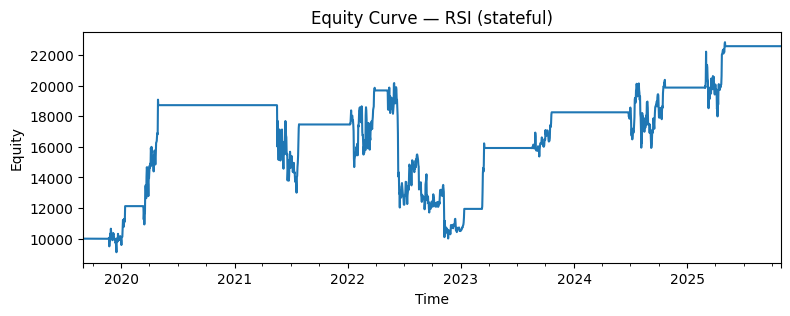

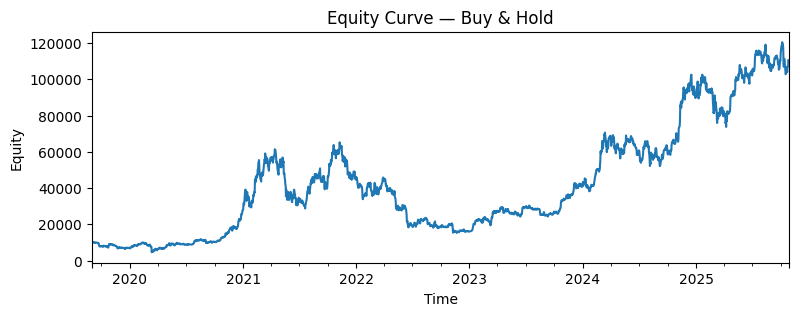


Rows with trades: 18


,close,ret,pos_prev,pos,trade,net_ret,equity
dt_utc,,,,,,,
2019-11-22 00:00:00+00:00,7262.9,-0.047688,0.0,1.0,1.0,-0.000700,9993.000000
2020-01-15 00:00:00+00:00,8819.2,0.000726,1.0,0.0,1.0,0.000026,12125.820152
2020-03-13 00:00:00+00:00,5574.3,0.162039,0.0,1.0,1.0,-0.000700,12117.332078
2020-04-30 00:00:00+00:00,8620.2,-0.018122,1.0,0.0,1.0,-0.018822,18725.106075
2021-05-18 00:00:00+00:00,42855.5,-0.016169,0.0,1.0,1.0,-0.000700,18711.998501
2021-07-29 00:00:00+00:00,40022.8,-0.000095,1.0,0.0,1.0,-0.000795,17462.922827
2022-01-08 00:00:00+00:00,41683.5,0.003013,0.0,1.0,1.0,-0.000700,17450.698781
2022-03-30 00:00:00+00:00,47059.9,-0.008012,1.0,0.0,1.0,-0.008712,19687.613486


In [ ]:
# CELL 5 — Backtest RSI (stateful) + kiểm chứng + so sánh BH
import numpy as np, pandas as pd, matplotlib.pyplot as plt

class Backtester:
    def __init__(self, fee_bps=5, slippage_bps=2, start_cash=10_000):
        self.fee = fee_bps / 10_000.0
        self.slip = slippage_bps / 10_000.0
        self.start_cash = float(start_cash)

    def run(self, df_sig: pd.DataFrame):
        df = df_sig.copy()
        assert {"close","signal"} <= set(df.columns)
        df["ret"] = df["close"].pct_change().fillna(0.0)

        df["pos"] = df["signal"].astype(float).fillna(0)
        df["pos_prev"] = df["pos"].shift(1).fillna(0.0)
        df["trade"] = (df["pos"] - df["pos_prev"]).abs()

        gross = df["pos_prev"] * df["ret"]
        cost  = df["trade"] * (self.fee + self.slip)
        df["net_ret"] = gross - cost
        df["equity"]  = (1 + df["net_ret"]).cumprod() * self.start_cash

        daily = df["net_ret"].replace([np.inf,-np.inf],0).fillna(0)
        cumret = (1 + daily).prod() - 1
        sharpe = np.sqrt(252) * daily.mean() / (daily.std(ddof=0) + 1e-12)
        roll = (1 + daily).cumprod()
        mdd = (roll / roll.cummax() - 1).min()

        report = {
            "Cumulative Return": float(cumret),
            "Sharpe (daily,252)": float(sharpe),
            "Max Drawdown": float(mdd),
            "Trades": int(df["trade"].sum()),
            "Exposure %": float((df["pos_prev"]>0).mean()*100)
        }
        return df, report

# 1) Run RSI (stateful)
bt = Backtester(fee_bps=FEE_BPS, slippage_bps=SLIPPAGE_BPS, start_cash=START_CASH)
res_rsi, rep_rsi = bt.run(rsi_df[["close","signal"]])

print("=== RSI (stateful) REPORT ===")
for k,v in rep_rsi.items(): print(f"{k}: {v:.6f}" if isinstance(v,float) else f"{k}: {v}")

# 2) No-lookahead check: pos_prev == signal.shift(1)
sig_shifted = rsi_df["signal"].shift(1).reindex(res_rsi.index).fillna(0).astype(float)
assert np.allclose(res_rsi["pos_prev"].values, sig_shifted.values), "Lookahead detected!"

# 3) Benchmark Buy&Hold
bh = rsi_df[["close"]].copy()
bh["signal"] = 1
bh["signal"] = bh["signal"].shift(1).fillna(0).astype(int)
res_bh, rep_bh = bt.run(bh)

print("\n=== BUY & HOLD REPORT ===")
for k,v in rep_bh.items(): print(f"{k}: {v:.6f}" if isinstance(v,float) else f"{k}: {v}")

# 4) Plot equity
plt.figure(figsize=(9,3))
res_rsi["equity"].plot(); plt.title("Equity Curve — RSI (stateful)"); plt.xlabel("Time"); plt.ylabel("Equity"); plt.show()

plt.figure(figsize=(9,3))
res_bh["equity"].plot(); plt.title("Equity Curve — Buy & Hold"); plt.xlabel("Time"); plt.ylabel("Equity"); plt.show()

# 5) Trade blotter (xem nhanh 8 giao dịch đầu)
blotter = res_rsi.loc[res_rsi["trade"]>0, ["close","ret","pos_prev","pos","trade","net_ret","equity"]]
print("\nRows with trades:", len(blotter))
display(blotter.head(8))


In [ ]:
# CELL 6 — Phân tích & diễn giải (regime + sensitivity) — 1 cell duy nhất

import pandas as pd, numpy as np

def metrics_from_equity(res_df):
    daily = res_df["net_ret"].replace([np.inf,-np.inf],0).fillna(0)
    cumret = (1+daily).prod()-1
    sharpe = np.sqrt(252)*daily.mean()/(daily.std(ddof=0)+1e-12)
    roll = (1+daily).cumprod()
    mdd = (roll/roll.cummax()-1).min()
    trades = int((res_df["trade"]>0).sum())
    exposure = float((res_df["pos_prev"]>0).mean()*100)
    return {"CumRet":float(cumret),"Sharpe":float(sharpe),"MDD":float(mdd),"Trades":trades,"Exposure%":exposure}

# 1) So sánh gọn RSI (đang có) vs BH
summary = pd.DataFrame({
    "RSI_stateful": metrics_from_equity(res_rsi),
    "BuyHold":      metrics_from_equity(res_bh)
}).T
display(summary)

# 2) Regime breakdown (SMA200 & dốc lên/xuống)
reg = df[["close"]].copy()
reg["sma200"] = reg["close"].rolling(200).mean()
reg["slope"]  = reg["sma200"].diff()
reg["bull"]   = (reg["close"] > reg["sma200"]) & (reg["slope"] > 0)
reg = reg["bull"].reindex(res_rsi.index).fillna(False)

def regime_metrics(res_df, mask, name):
    sub = res_df.loc[mask].copy()
    if sub.empty:
        return {f"{name}_CumRet": np.nan, f"{name}_Sharpe": np.nan}
    d = sub["net_ret"].fillna(0)
    return {
        f"{name}_CumRet": float((1+d).prod()-1),
        f"{name}_Sharpe": float(np.sqrt(252)*d.mean()/(d.std(ddof=0)+1e-12))
    }

reg_summary = {
    **regime_metrics(res_rsi, reg, "Bull"),
    **regime_metrics(res_rsi, ~reg, "Bear"),
}
print("\nRSI Regime breakdown:", reg_summary)

# 3) Độ nhạy ngưỡng (period=14, grid ngưỡng đối xứng 25/75, 30/70, 35/65)
def rsi_series(close, period=14):
    diff = close.diff()
    gain = diff.clip(lower=0).ewm(alpha=1/period, adjust=False).mean()
    loss = -diff.clip(upper=0).ewm(alpha=1/period, adjust=False).mean()
    rs = gain/(loss.replace(0,np.nan)); rsi = 100 - (100/(1+rs))
    return rsi.fillna(50)

def rsi_stateful_signal(close, buy_th, sell_th, period=14):
    r = rsi_series(close, period)
    sig = np.zeros(len(r), dtype=int); in_pos = 0
    for i in range(1,len(r)):
        if in_pos==0 and r.iloc[i] < buy_th: in_pos=1
        elif in_pos==1 and r.iloc[i] > sell_th: in_pos=0
        sig[i]=in_pos
    sig = pd.Series(sig, index=r.index)
    return pd.DataFrame({"close":df["close"], "signal": sig.shift(1).fillna(0).astype(int)})

grid = [(25,75),(30,70),(35,65)]
rows=[]
bt = Backtester(fee_bps=FEE_BPS, slippage_bps=SLIPPAGE_BPS, start_cash=START_CASH)
for b,s in grid:
    sig = rsi_stateful_signal(df["close"], b, s)
    res,_ = bt.run(sig)
    m = metrics_from_equity(res); m["buy"], m["sell"] = b, s
    rows.append(m)
sens = pd.DataFrame(rows).set_index(["buy","sell"]).sort_index()
print("\nRSI threshold sensitivity (period=14):")
display(sens)


,CumRet,Sharpe,MDD,Trades,Exposure%
RSI_stateful,1.257992,0.446574,-0.503634,18.0,33.673923
BuyHold,9.850595,0.780638,-0.766257,1.0,99.911151



RSI Regime breakdown: {'Bull_CumRet': 1.7026457554210048, 'Bull_Sharpe': 1.3801235708921717, 'Bear_CumRet': -0.16452543909070783, 'Bear_Sharpe': 0.11969119450530787}

RSI threshold sensitivity (period=14):


,,CumRet,Sharpe,MDD,Trades,Exposure%
buy,sell,,,,,
25,75,2.538215,0.599856,-0.667296,12,34.651266
30,70,1.257992,0.446574,-0.503634,18,33.673923
35,65,1.112592,0.420854,-0.518219,30,36.250555


### Cell 7 — Grid Search RSI Thresholds (period=14)

**Mục tiêu:** Tìm cặp ngưỡng `buy_th`/`sell_th` cho RSI(14) tối đa **Sharpe**, giữ logic **stateful** (mua khi `RSI < buy_th`, giữ đến khi `RSI > sell_th`).

**Thiết lập tìm kiếm**
- Lưới: `buy_th ∈ [15, 45]` bước 2; `sell_th ∈ [55, 95]` bước 2  
- Ràng buộc: `sell_th − buy_th ≥ 20`, `MIN_TRADES ≥ 5` (loại nghiệm “ít lệnh”)
- Phí/slippage: giữ như Cell 1  
- Tiêu chí chọn: **Sharpe** cao nhất (trên toàn giai đoạn)

**Kết quả tốt nhất (sample run)**
- `buy = 21`, `sell = 89`  
- **Sharpe = 1.050**, **CumRet = 16.75**, **MDD = −0.667**, **Trades = 5**, **Exposure ≈ 64.90%**

**Ghi chú/giới hạn**
- Tối ưu **toàn mẫu** có nguy cơ **overfit**. Nên xác thực bằng **train/test theo thời gian** hoặc **walk-forward** trước khi dùng thực tế.
- Việc tăng `sell_th` rộng (≈89) kéo dài nắm giữ sau nhịp “quá bán”, giúp bắt xu hướng tiếp diễn, nhưng có thể nâng MDD.

**Tiếp theo (khuyến nghị báo cáo)**
- So sánh cấu hình mặc định (30/70) vs cấu hình tối ưu (21/89) ở các giai đoạn bull/bear.
- Minh hoạ equity và phân rã PnL theo regime để giải thích vì sao ngưỡng rộng hơn cải thiện Sharpe.


== BEST BY SHARPE (period=14) ==
buy          21.000000
sell         89.000000
Sharpe        1.050190
CumRet       16.753239
MDD          -0.667296
Trades        5.000000
Exposure%    64.904487

Top 10 theo Sharpe:


,Sharpe,CumRet,MDD,Trades,Exposure%,buy,sell
0,1.050190,16.753239,-0.667296,5,64.904487,21,89
1,0.917970,16.071563,-0.766257,5,88.049756,29,89
2,0.865286,14.367243,-0.766257,5,95.379831,43,89
3,0.853512,11.477256,-0.766257,5,80.808530,25,89
4,0.853512,11.477256,-0.766257,5,80.808530,23,89
5,0.846693,12.040664,-0.766257,5,89.204798,33,89
6,0.846254,11.134013,-0.766257,5,80.897379,27,89
7,0.827790,11.263854,-0.766257,5,90.581964,37,89
8,0.825326,11.134636,-0.766257,5,90.626388,39,89
9,0.825139,10.849174,-0.766257,5,89.160373,31,89


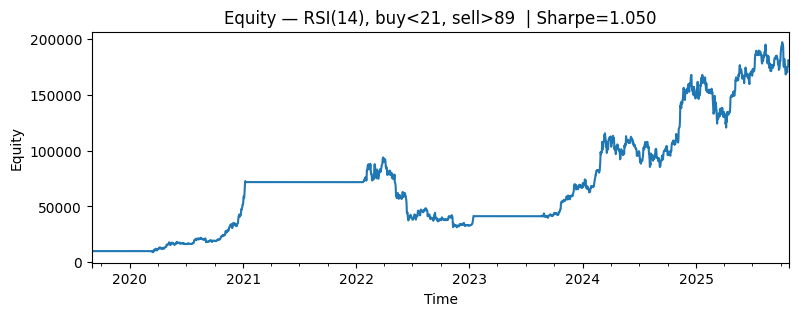

In [ ]:
# CELL 7 — Grid search RSI thresholds (period=14) tối ưu Sharpe

import numpy as np, pandas as pd, matplotlib.pyplot as plt

MIN_TRADES = 5                    # loại nghiệm quá ít lệnh
BUY_GRID  = list(range(15, 45, 2))   # thử từ 15 đến 45 bước nhảy là 2
SELL_GRID = list(range(55, 95, 2))   # thử từ 55 đến 95 bước nhảy là 2
GAP_MIN   = 20                    # yêu cầu sell - buy >= GAP_MIN

def rsi_stateful_signal_df(close: pd.Series, buy_th: int, sell_th: int, period: int = 14) -> pd.DataFrame:
    # sử dụng rsi_series đã định nghĩa ở Cell 4
    r = rsi_series(close, period)
    sig = np.zeros(len(r), dtype=int); in_pos = 0
    for i in range(1, len(r)):
        if in_pos == 0 and r.iloc[i] < buy_th: in_pos = 1
        elif in_pos == 1 and r.iloc[i] > sell_th: in_pos = 0
        sig[i] = in_pos
    sig = pd.Series(sig, index=r.index).shift(1).fillna(0).astype(int)
    return pd.DataFrame({"close": close, "signal": sig})

def metrics_from_res(res_df: pd.DataFrame) -> dict:
    daily = res_df["net_ret"].replace([np.inf,-np.inf],0).fillna(0)
    sharpe = np.sqrt(252)*daily.mean()/(daily.std(ddof=0)+1e-12)
    cumret = (1+daily).prod()-1
    roll = (1+daily).cumprod()
    mdd = (roll/roll.cummax()-1).min()
    trades = int((res_df["trade"]>0).sum())
    exposure = float((res_df["pos_prev"]>0).mean()*100)
    return {"Sharpe": float(sharpe), "CumRet": float(cumret), "MDD": float(mdd),
            "Trades": trades, "Exposure%": exposure}

# chạy grid
bt = Backtester(fee_bps=FEE_BPS, slippage_bps=SLIPPAGE_BPS, start_cash=START_CASH)
rows = []
for b in BUY_GRID:
    for s in SELL_GRID:
        if s - b < GAP_MIN:
            continue
        sig_df = rsi_stateful_signal_df(df["close"], buy_th=b, sell_th=s, period=14)
        res, _ = bt.run(sig_df)
        m = metrics_from_res(res)
        m.update({"buy": b, "sell": s})
        rows.append(m)

grid_df = pd.DataFrame(rows).sort_values("Sharpe", ascending=False)

# lọc theo số lệnh tối thiểu
grid_df_filtered = grid_df[grid_df["Trades"] >= MIN_TRADES].copy()
best = grid_df_filtered.iloc[0]
print("== BEST BY SHARPE (period=14) ==")
print(best[["buy","sell","Sharpe","CumRet","MDD","Trades","Exposure%"]].to_string())

# hiển thị top 10
print("\nTop 10 theo Sharpe:")
display(grid_df_filtered.head(10).reset_index(drop=True))

# vẽ equity của cấu hình tốt nhất
best_sig = rsi_stateful_signal_df(df["close"], int(best["buy"]), int(best["sell"]), period=14)
best_res, _ = bt.run(best_sig)
plt.figure(figsize=(9,3))
best_res["equity"].plot()
plt.title(f"Equity — RSI(14), buy<{int(best['buy'])}, sell>{int(best['sell'])}  | Sharpe={best['Sharpe']:.3f}")
plt.xlabel("Time"); plt.ylabel("Equity"); plt.show()
